# Multiple Refractive Index DDA Support - Data Analysis

3 different algorithms for ways to differentiate between refractive indicies for the Discrete Dipole Approximation needed to be benchmarked for speed. This was tested on two systems, a `Ryzen 7 9800X3D` system with `64GB DDR5` & a `M1 Macbook Pro (10 Core Variant)` with `32GB unified memory`.

_Note, any mention of refractive index is actually the inverse polarisability_


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Algorithms
### Boolean Mask

A C++ vector that holds a series of `true/false` values was used to store whever the first refractive index or the second refractive index should be used. This vector is built every timestep however...

### Linear Search

Two arrays that store the indices of `dipole_primitive` that represent each refractive index is searched through within the DDA for loop. If a match is found in either array, then that refractive index is used. Once again, this is done every timestep (and every iteration)...

### Merging all Refractive Indicies to One Array

An array that stores all the inverse polarisabilities that map to each dipole in `dipole_primitive` is iterated over for the DDA. The (_effective_) `main()` code in the library seems to already be able to map each refractive index to their respective particle.

## Loading Data
### `M1 Pro`

In [11]:
processor = "M1-Pro"
M1_Pro_boolMask_df = pd.read_csv(f"{processor}/DDA-Multi-Particle-TestSuite/BooleanMask/{processor}-DDA-BooleanMask.txt", sep = "\t", names = ["Dipoles", "Time (s)"])
M1_Pro_linearSearch_df = pd.read_csv(f"{processor}/DDA-Multi-Particle-TestSuite/LinearSearch/{processor}-DDA-LinearSearch.txt", sep = "\t", names = ["Dipoles", "Time (s)"])
M1_Pro_mergeAllPolarisabilities_df = pd.read_csv(f"{processor}/DDA-Multi-Particle-TestSuite/MergeAllPolarisabilities/{processor}-DDA-MergeAllPolarisabilities.txt", sep = "\t", names = ["Dipoles", "Time (s)"])
display(M1_Pro_boolMask_df)
display(M1_Pro_linearSearch_df)
display(M1_Pro_mergeAllPolarisabilities_df)


,Dipoles,Time (s)
0,8,0.014345
1,32,0.041071
2,56,0.137471
3,160,1.300436
4,552,19.841889
5,4224,3024.629291
6,8,0.014504
7,32,0.041506
8,56,0.147393
9,160,1.218663


,Dipoles,Time (s)
0,8,0.014674
1,32,0.042303
2,56,0.142714
3,160,1.398930
4,552,19.992226
5,4224,3026.586557
6,8,0.014170
7,32,0.042406
8,56,0.156271
9,160,1.401608


,Dipoles,Time (s)
0,8,0.014083
1,32,0.042814
2,56,0.137324
3,160,1.672333
4,552,20.353522
5,4224,2989.441167
6,8,0.013747
7,32,0.040986
8,56,0.137977
9,160,1.298408


### `Ryzen 7 9800X3D`

In [12]:
processor = "R7-9800X3D" # May compare to Ryzen 7 9800X3D later
R7_9800X3D_boolMask_df = pd.read_csv(f"{processor}/DDA-Multi-Particle-TestSuite/BooleanMask/{processor}-DDA-BooleanMask.txt", sep = "\t", names = ["Dipoles", "Time (s)"])
R7_9800X3D_linearSearch_df = pd.read_csv(f"{processor}/DDA-Multi-Particle-TestSuite/LinearSearch/{processor}-DDA-LinearSearch.txt", sep = "\t", names = ["Dipoles", "Time (s)"])
R7_9800X3D_mergeAllPolarisabilities_df = pd.read_csv(f"{processor}/DDA-Multi-Particle-TestSuite/MergeAllPolarisabilities/{processor}-DDA-MergeAllPolarisabilities.txt", sep = "\t", names = ["Dipoles", "Time (s)"])
display(R7_9800X3D_boolMask_df)
display(R7_9800X3D_linearSearch_df)
display(R7_9800X3D_mergeAllPolarisabilities_df)

,Dipoles,Time (s)
0,8,0.018028
1,32,0.047519
2,56,0.126024
3,160,1.525719
4,552,33.026789
5,4224,5799.105295


,Dipoles,Time (s)
0,8,0.011133
1,32,0.047693
2,56,0.126409
3,160,1.546125
4,552,33.508100
5,4224,5812.958786


,Dipoles,Time (s)
0,8,0.010503
1,32,0.046888
2,56,0.122053
3,160,1.579792
4,552,33.885119
5,4224,5793.223457


#### Original Code Benchmark

In [17]:
processor = "M1-Pro"
M1_Pro_ORIGINAL_df = pd.read_csv(f"{processor}/DDA-Multi-Particle-TestSuite/Original-Program-DO-NOT-TOUCH/M1-Pro-DDA-ORIGINAL.txt", sep = "\t", names = ["Dipoles", "Time (s)"])
display(M1_Pro_ORIGINAL_df)

,Dipoles,Time (s)
0,8,0.011927
1,32,0.040799
2,56,0.136321
3,160,1.346188
4,552,20.320211
5,4224,3062.066491
6,8,0.011415
7,32,0.039636
8,56,0.137099
9,160,1.279558


## Other Pandas Funky-ness

In [18]:
all_df = pd.concat([
    M1_Pro_boolMask_df.assign(Processor="M1 Pro", Algorithm="Boolean mask"),
    M1_Pro_linearSearch_df.assign(Processor="M1 Pro", Algorithm="Linear search"),
    M1_Pro_mergeAllPolarisabilities_df.assign(
        Processor="M1 Pro", Algorithm="Merged polarisabilities"
    ),
    M1_Pro_ORIGINAL_df.assign(
        Processor="M1 Pro", Algorithm="ORIGINAL"
    ),

    R7_9800X3D_boolMask_df.assign(Processor="Ryzen 7 9800X3D", Algorithm="Boolean mask"),
    R7_9800X3D_linearSearch_df.assign(Processor="Ryzen 7 9800X3D", Algorithm="Linear search"),
    R7_9800X3D_mergeAllPolarisabilities_df.assign(
        Processor="Ryzen 7 9800X3D", Algorithm="Merged polarisabilities"
    ),
], ignore_index=True)



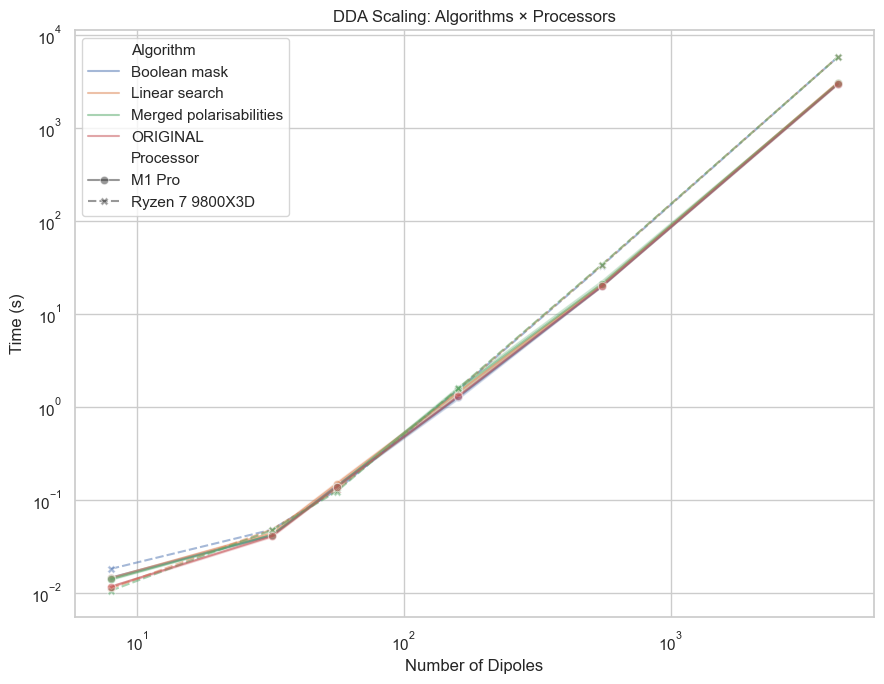

In [19]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 7))

sns.lineplot(
    data=all_df,
    x="Dipoles",
    y="Time (s)",
    hue="Algorithm",
    style="Processor",
    markers=True,
    dashes=True,
    ax=ax,
    alpha = 0.5
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("DDA Scaling: Algorithms × Processors")
ax.set_xlabel("Number of Dipoles")
ax.set_ylabel("Time (s)")

plt.tight_layout()
plt.show()

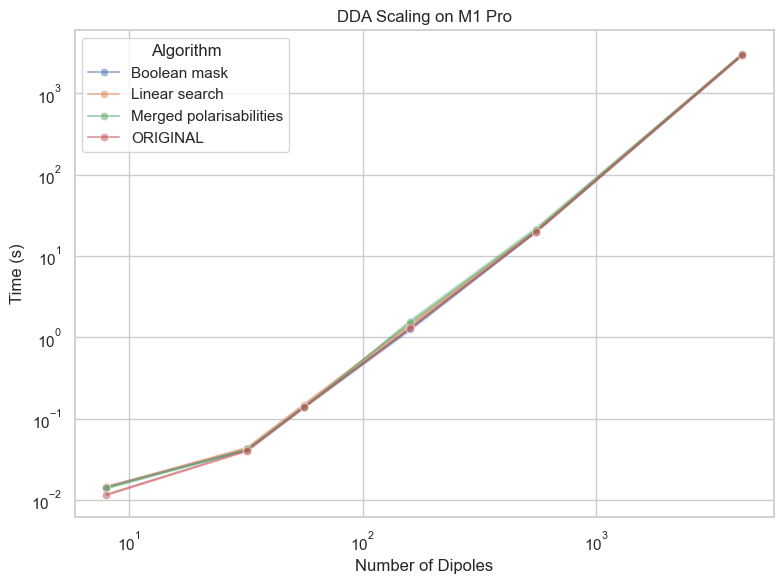

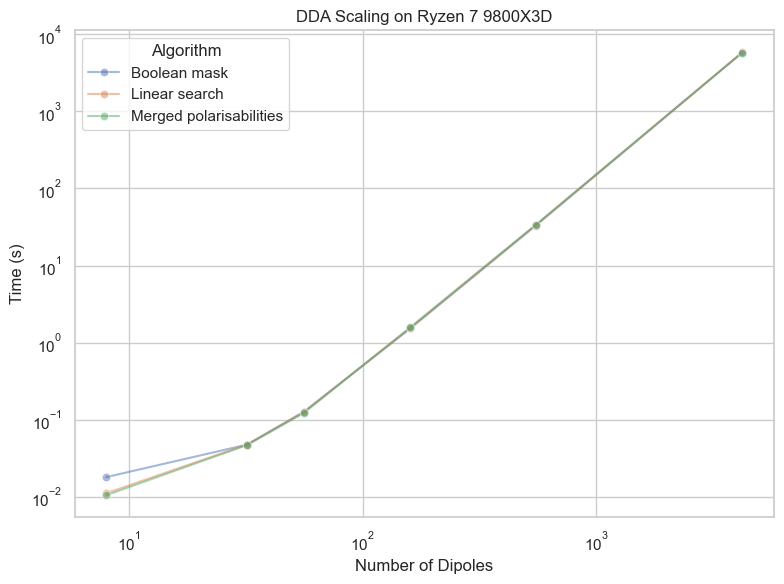

In [20]:
sns.set_theme(style="whitegrid")

processors = all_df["Processor"].unique()

for proc in processors:
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.lineplot(
        data=all_df[all_df["Processor"] == proc],
        x="Dipoles",
        y="Time (s)",
        hue="Algorithm",
        marker="o",
        ax=ax,
        alpha = 0.5
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(f"DDA Scaling on {proc}")
    ax.set_xlabel("Number of Dipoles")
    ax.set_ylabel("Time (s)")

    plt.tight_layout()
    plt.show()

## Comments

Generally, merging all the polarisabilities together into one array that maps to each dipole in `dipole_primitive` is the best solution in terms of scalability. However, quirks from parallelising with the M1 Pro with 10 cores (8 performance and 2 efficiency) may be the reason for the 160 dipole time measurements scaling worse compared to other methods. This is less of an issue with teh Ryzen 7 9800X3D however the Merged polarisabilities method is still the slowest using the same numnber of dipoles.

The M1 pro has also proven to run the quicker than the Ryzen 7 9800X3D which is likely due to its unified memory architecture and the former having 3 times the L2 cache. My initial thoughts would have been that the Ryzen 7 9800X3D would win due to it having immense amounts of L3 cache but I suppose clearly not... Perhaps having more cores (even if 2 of them are efficiency ones) is more favourable as well.

In credit to us, we seemed to have been able to produce code that is as efficient with respect to time as the original. Albeit, many readings could be made in order to calculate an error. We also however, only have limited resources and time so it seems to just be better to move on...